In [1]:
from google.colab import drive
drive.mount('/content/drive')

# Defina onde você vai guardar o projeto no Drive
PROJECT_DIR = '/content/drive/MyDrive/dga_project'

import os
os.makedirs(f'{PROJECT_DIR}/datasets', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/dga_classifier', exist_ok=True)

# Muda o diretório de trabalho para o projeto
os.chdir(PROJECT_DIR)
print("Diretório atual:", os.getcwd())

Mounted at /content/drive
Diretório atual: /content/drive/MyDrive/dga_project


In [2]:
# TensorFlow já vem no Colab. Instale apenas o que falta:
!pip install hmmlearn --quiet

# Verificação das versões
import tensorflow as tf
import sklearn
import hmmlearn
print(f"TensorFlow: {tf.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")
print(f"hmmlearn: {hmmlearn.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 14.4 MB/s eta 0:00:00
TensorFlow: 2.20.0
Scikit-learn: 1.6.1
hmmlearn: 0.3.3


In [3]:
# Verificação dos arquivos
import pandas as pd

df_dga = pd.read_csv('datasets/bambenek_dga_domain_30.csv')
df_alexa = pd.read_csv('datasets/top-1m.csv', header=None, names=['rank','domain'])

print(f"DGA dataset: {len(df_dga)} linhas, {df_dga['DGA_family'].nunique()} famílias")
print(f"Alexa dataset: {len(df_alexa)} linhas")
print("\nFamílias DGA:")
print(df_dga['DGA_family'].value_counts())

DGA dataset: 828454 linhas, 30 famílias
Alexa dataset: 1000000 linhas

Famílias DGA:
DGA_family
banjori                   439223
tinba                      66688
Post                       66000
ramnit                     56174
qakbot                     40000
necurs                     32768
murofet                    28520
ranbyus                    26040
simda                      14755
pykspa                     14215
shiotob/urlzone/bebloh     12521
dyre                        7998
nymaim                      6000
Cryptolocker                6000
shifu                       2331
P2P                         2000
pushdo                      1680
suppobox                    1014
Volatile                     996
dircrypt                     720
fobber                       600
geodo                        576
symmi                        384
corebot                      280
tempedreve                   249
beebone                      210
hesperbot                    192
bedep        

In [4]:
# Estrutura esperada no PROJECT_DIR:
# dga_project/
# ├── datasets/
# │   ├── bambenek_dga_domain_30.csv
# │   └── top-1m.csv
# ├── dga_classifier/
# │   ├── __init__.py
# │   ├── data.py
# │   ├── lstm.py
# │   ├── bigram.py
# │   ├── randomforest.py
# │   └── hmm.py
# └── run.py

import os
for f in ['dga_classifier/__init__.py', 'dga_classifier/data.py',
          'dga_classifier/lstm.py', 'dga_classifier/bigram.py',
          'dga_classifier/randomforest.py', 'dga_classifier/hmm.py',
          'run.py']:
    exists = os.path.exists(f)
    status = "✓" if exists else "✗ FALTANDO"
    print(f"  {status} {f}")

  ✓ dga_classifier/__init__.py
  ✓ dga_classifier/data.py
  ✓ dga_classifier/lstm.py
  ✓ dga_classifier/bigram.py
  ✓ dga_classifier/randomforest.py
  ✓ dga_classifier/hmm.py
  ✓ run.py


In [5]:
# Execute este bloco para validar que o data.py está funcionando
import sys
sys.path.insert(0, PROJECT_DIR)  # garante que o pacote seja encontrado

import dga_classifier.data as data
from importlib import reload
reload(data)

# Carrega com amostragem pequena para teste rápido
indata = data.get_data(samples_per_family=100)

print(f"\nTotal de amostras: {len(indata)}")
print(f"Exemplo: {indata[0]}")  # ('dga', 'dominio', 'familia')
print(f"Exemplo: {indata[-1]}")

# Distribuição das classes
from collections import Counter
labels = [x[0] for x in indata]
families = [x[2] for x in indata]
print(f"\nDistribuição binária: {Counter(labels)}")
print(f"\nFamílias únicas: {sorted(set(families))}")

[data] Lendo DGA de: datasets/bambenek_dga_domain_30.csv
[data] DGA carregados: 2942
[data] Lendo Alexa de: datasets/top-1m.csv
[data] Benignos carregados: 2942
[data] Total de amostras: 5884

Total de amostras: 5884
Exemplo: ('dga', 'chptckv', 'nymaim')
Exemplo: ('benign', 'egglandsbest', 'benign')

Distribuição binária: Counter({'dga': 2942, 'benign': 2942})

Famílias únicas: ['banjori', 'bedep', 'beebone', 'benign', 'corebot', 'cryptolocker', 'cryptowall', 'dircrypt', 'dyre', 'fobber', 'geodo', 'hesperbot', 'matsnu', 'murofet', 'necurs', 'nymaim', 'p2pgameoverzeus', 'posttovargoz', 'pushdo', 'pykspa', 'qakbot', 'ramnit', 'ranbyus', 'shifu', 'shiotob', 'simda', 'suppobox', 'symmi', 'tempedreve', 'tinba', 'volatilecedar']



=== Bigrams ===
[data] Lendo DGA de: datasets/bambenek_dga_domain_30.csv
[data] DGA carregados: 39221
[data] Lendo Alexa de: datasets/top-1m.csv
[data] Benignos carregados: 39221
[data] Total de amostras: 78442
[bigram] Vetorizando bigramas...
[bigram] fold 1/1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  epoch 0: holdout auc=0.9452 (best=0.0000)
  epoch 1: holdout auc=0.9581 (best=0.9452)
  epoch 2: holdout auc=0.9644 (best=0.9581)
  epoch 3: holdout auc=0.9679 (best=0.9644)
  epoch 4: holdout auc=0.9700 (best=0.9679)
  epoch 5: holdout auc=0.9714 (best=0.9700)
  epoch 6: holdout auc=0.9723 (best=0.9714)
  epoch 7: holdout auc=0.9731 (best=0.9723)
  epoch 8: holdout auc=0.9737 (best=0.9731)
  epoch 9: holdout auc=0.9741 (best=0.9737)
  epoch 10: holdout auc=0.9745 (best=0.9741)
  epoch 11: holdout auc=0.9747 (best=0.9745)
  epoch 12: holdout auc=0.9749 (best=0.9747)
  epoch 13: holdout auc=0.9751 (best=0.9749)
  epoch 14: holdout auc=0.9753 (best=0.9751)
  epoch 15: holdout auc=0.9753 (best=0.9753)
  epoch 16: holdout auc=0.9754 (best=0.9753)
  epoch 17: holdout auc=0.9755 (best=0.9754)
  epoch 18: holdout auc=0.9756 (best=0.9755)
  epoch 19: holdout auc=0.9757 (best=0.9756)
  epoch 20: holdout auc=0.9757 (best=0.9757)
  epoch 21: holdout auc=0.9757 (best=0.9757)
  epoch 22: holdout 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


  epoch 0: holdout auc=0.9445 (best=0.0000)
  epoch 1: holdout auc=0.9505 (best=0.9445)
  epoch 2: holdout auc=0.9514 (best=0.9505)
  epoch 3: holdout auc=0.9611 (best=0.9514)
  epoch 4: holdout auc=0.9675 (best=0.9611)
  epoch 5: holdout auc=0.9731 (best=0.9675)
  epoch 6: holdout auc=0.9772 (best=0.9731)
  epoch 7: holdout auc=0.9791 (best=0.9772)
  epoch 8: holdout auc=0.9807 (best=0.9791)
  epoch 9: holdout auc=0.9834 (best=0.9807)
  epoch 10: holdout auc=0.9852 (best=0.9834)
  epoch 11: holdout auc=0.9871 (best=0.9852)
  epoch 12: holdout auc=0.9877 (best=0.9871)
  epoch 13: holdout auc=0.9887 (best=0.9877)
  epoch 14: holdout auc=0.9901 (best=0.9887)
  epoch 15: holdout auc=0.9898 (best=0.9901)
  epoch 16: holdout auc=0.9901 (best=0.9901)
  epoch 17: holdout auc=0.9915 (best=0.9901)
  epoch 18: holdout auc=0.9921 (best=0.9915)
  epoch 19: holdout auc=0.9916 (best=0.9921)
  epoch 20: holdout auc=0.9919 (best=0.9921)
  epoch 21: holdout auc=0.9920 (best=0.9921)
  early stop at epoc

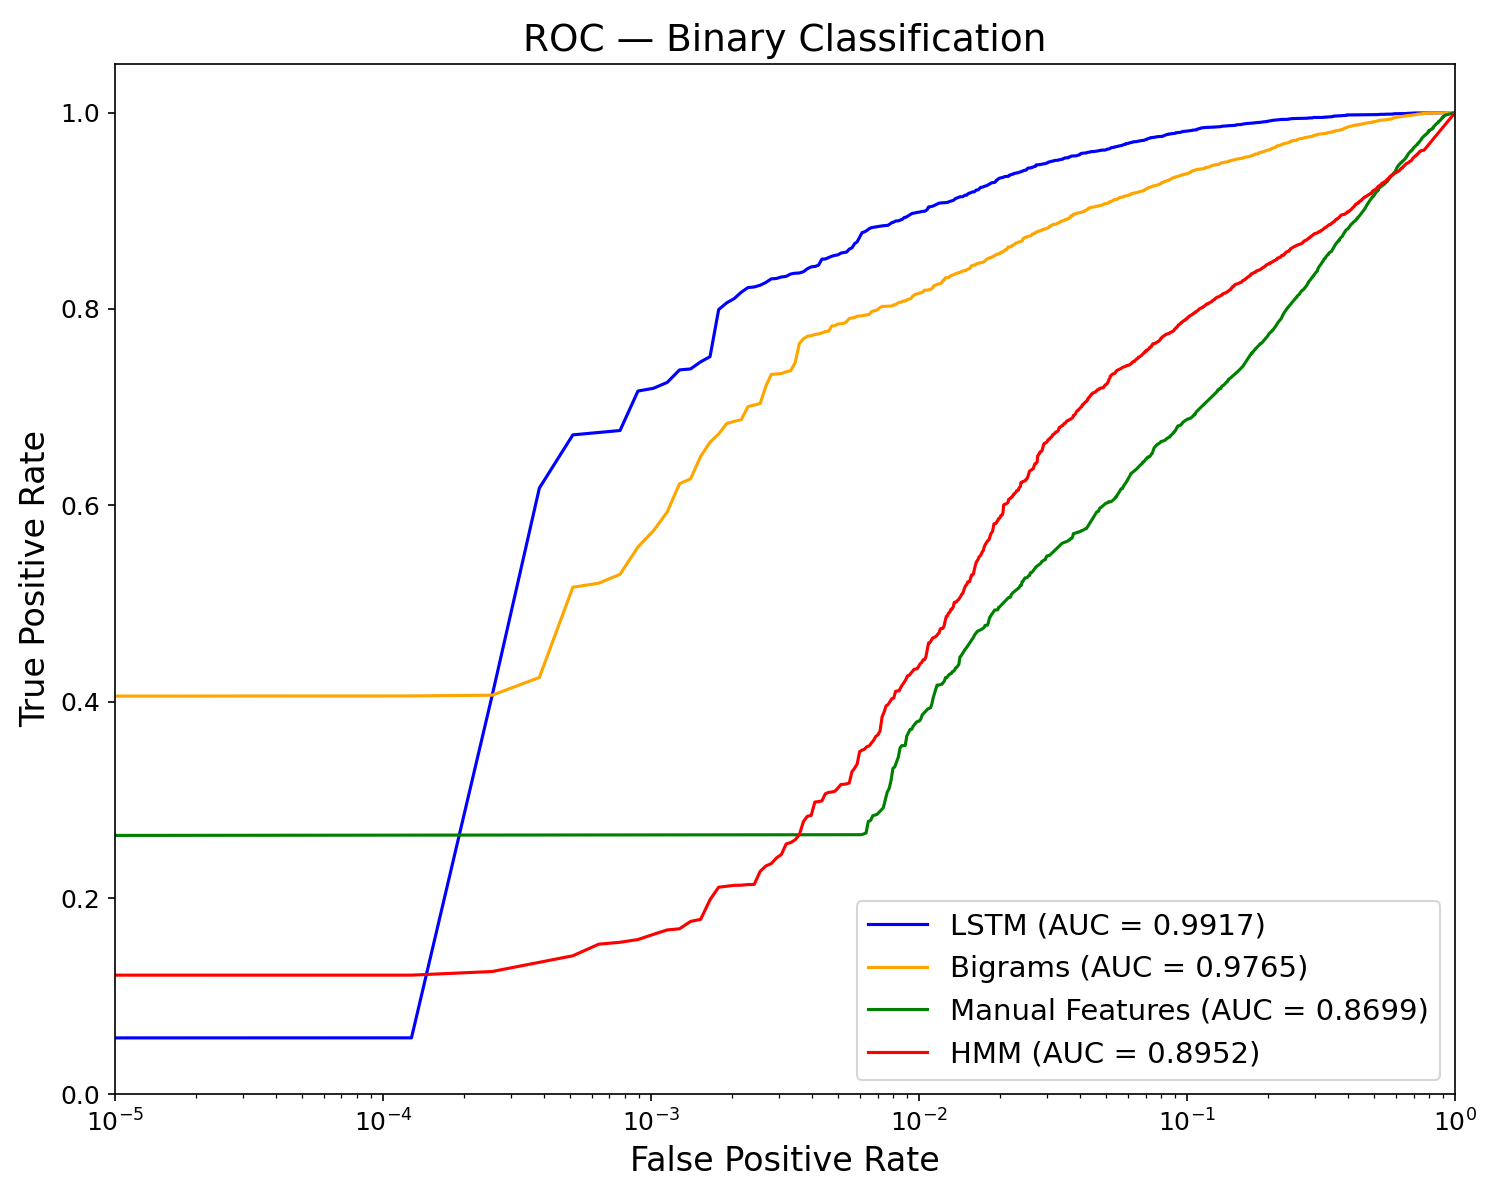

In [6]:
import run as run_module
from importlib import reload
reload(run_module)

# TESTE RÁPIDO (1 fold)
run_module.create_figs(
    isbigram=True,
    islstm=True,
    isrf=True,
    ishmm=True,   # HMM é mais lento; mude para False se quiser pular
    nfolds=1,
    force=True,
)

# Exibir a figura gerada
from IPython.display import Image
Image('results_roc.png')

In [7]:
lco_results = run_module.run_leave_class_out_experiment()

# Tabela III do artigo — valores de referência para comparação:
# bedep: 0.99 | beebone: 0.00 | corebot: 0.77 | cryptowall: 0.20
# dircrypt: 0.97 | fobber: 0.99 | hesperbot: 0.92 | matsnu: 0.00
# symmi: 0.06 | tempedreve: 0.84


=== Experimento 2: Leave-Class-Out ===
[data] Lendo DGA de: datasets/bambenek_dga_domain_30.csv
[data] DGA carregados: 39221
[data] Lendo Alexa de: datasets/top-1m.csv
[data] Benignos carregados: 39221
[data] Total de amostras: 78442


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


[lstm lco] Treinando modelo Leave-Class-Out...
  epoch 0: holdout auc=0.9513 (best=0.0000)
  recall por família: {'bedep': 0.949438202247191, 'beebone': 0.0, 'corebot': 0.7642857142857142, 'cryptowall': 0.1276595744680851, 'dircrypt': 0.9416666666666667, 'fobber': 0.945, 'hesperbot': 0.859375, 'matsnu': 0.041666666666666664, 'symmi': 0.015625, 'tempedreve': 0.8072289156626506}
  epoch 1: holdout auc=0.9598 (best=0.9513)
  recall por família: {'bedep': 0.949438202247191, 'beebone': 0.0, 'corebot': 0.7678571428571429, 'cryptowall': 0.13829787234042554, 'dircrypt': 0.9583333333333334, 'fobber': 0.94, 'hesperbot': 0.8802083333333334, 'matsnu': 0.020833333333333332, 'symmi': 0.0, 'tempedreve': 0.8393574297188755}
  epoch 2: holdout auc=0.9651 (best=0.9598)
  recall por família: {'bedep': 0.9719101123595506, 'beebone': 0.0, 'corebot': 0.8, 'cryptowall': 0.19148936170212766, 'dircrypt': 0.9666666666666667, 'fobber': 0.9683333333333334, 'hesperbot': 0.9010416666666666, 'matsnu': 0.0625, 'symmi

In [8]:
# Multiclasse por família individual (Tabela IV)
multi_familia = run_module.run_multiclass_experiment(use_superfamilies=False, nfolds=1)

# Multiclasse por superfamília (Tabela VI)
multi_super = run_module.run_multiclass_experiment(use_superfamilies=True, nfolds=1)


=== Experimento 3: Multiclasse (familias) ===
[data] Lendo DGA de: datasets/bambenek_dga_domain_30.csv
[data] DGA carregados: 39221
[data] Lendo Alexa de: datasets/top-1m.csv
[data] Benignos carregados: 39221
[data] Total de amostras: 78442
[lstm multiclass] fold 1/1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


  epoch 0: holdout acc=0.6816 (best=0.0000)
  epoch 1: holdout acc=0.7572 (best=0.6816)
  epoch 2: holdout acc=0.7769 (best=0.7572)
  epoch 3: holdout acc=0.8043 (best=0.7769)
  epoch 4: holdout acc=0.8113 (best=0.8043)
  epoch 5: holdout acc=0.8158 (best=0.8113)
  epoch 6: holdout acc=0.8225 (best=0.8158)
  epoch 7: holdout acc=0.8257 (best=0.8225)
  epoch 8: holdout acc=0.8273 (best=0.8257)
  epoch 9: holdout acc=0.8053 (best=0.8273)
  epoch 10: holdout acc=0.8349 (best=0.8273)
  epoch 11: holdout acc=0.8438 (best=0.8349)
  epoch 12: holdout acc=0.8410 (best=0.8438)
  epoch 13: holdout acc=0.8435 (best=0.8438)
  epoch 14: holdout acc=0.8470 (best=0.8438)
  epoch 15: holdout acc=0.8407 (best=0.8470)
  epoch 16: holdout acc=0.8458 (best=0.8470)
  epoch 17: holdout acc=0.8435 (best=0.8470)
  early stop at epoch 17

--- Fold 1 ---
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       407
           1       0.61      0.29      0.39       

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


  epoch 0: holdout acc=0.8537 (best=0.0000)
  epoch 1: holdout acc=0.8595 (best=0.8537)
  epoch 2: holdout acc=0.9047 (best=0.8595)
  epoch 3: holdout acc=0.9178 (best=0.9047)
  epoch 4: holdout acc=0.9222 (best=0.9178)
  epoch 5: holdout acc=0.9293 (best=0.9222)
  epoch 6: holdout acc=0.9280 (best=0.9293)
  epoch 7: holdout acc=0.9318 (best=0.9293)
  epoch 8: holdout acc=0.9369 (best=0.9318)
  epoch 9: holdout acc=0.9395 (best=0.9369)
  epoch 10: holdout acc=0.9414 (best=0.9395)
  epoch 11: holdout acc=0.9442 (best=0.9414)
  epoch 12: holdout acc=0.9461 (best=0.9442)
  epoch 13: holdout acc=0.9433 (best=0.9461)
  epoch 14: holdout acc=0.9503 (best=0.9461)
  epoch 15: holdout acc=0.9509 (best=0.9503)
  epoch 16: holdout acc=0.9509 (best=0.9509)
  epoch 17: holdout acc=0.9519 (best=0.9509)
  epoch 18: holdout acc=0.9474 (best=0.9519)
  epoch 19: holdout acc=0.9519 (best=0.9519)
  epoch 20: holdout acc=0.9516 (best=0.9519)
  early stop at epoch 20

--- Fold 1 ---
              precision 

In [9]:
import pickle
import pandas as pd
import sklearn.metrics

# Carrega resultados binários salvos
with open('results_binary.pkl', 'rb') as f:
    results = pickle.load(f)

# Calcula Precision, Recall, F1 para cada modelo
for model_name, fold_results in results.items():
    if not fold_results:
        continue
    all_y, all_pred = [], []
    for res in fold_results:
        probs = res['probs']
        if hasattr(probs, 'ndim') and probs.ndim == 2:
            probs = probs[:, 1]
        preds = (probs > 0.5).astype(int)
        all_y.extend(res['y'])
        all_pred.extend(preds)

    print(f"\n{'='*40}")
    print(f"Modelo: {model_name.upper()}")
    print(sklearn.metrics.classification_report(all_y, all_pred,
          target_names=['Benign', 'DGA']))


Modelo: BIGRAM
              precision    recall  f1-score   support

      Benign       0.91      0.95      0.93      7829
         DGA       0.95      0.91      0.93      7860

    accuracy                           0.93     15689
   macro avg       0.93      0.93      0.93     15689
weighted avg       0.93      0.93      0.93     15689


Modelo: LSTM
              precision    recall  f1-score   support

      Benign       0.96      0.96      0.96      7829
         DGA       0.96      0.96      0.96      7860

    accuracy                           0.96     15689
   macro avg       0.96      0.96      0.96     15689
weighted avg       0.96      0.96      0.96     15689


Modelo: RF
              precision    recall  f1-score   support

      Benign       0.76      0.87      0.81      7883
         DGA       0.84      0.72      0.78      7806

    accuracy                           0.79     15689
   macro avg       0.80      0.79      0.79     15689
weighted avg       0.80      0.7